# Variant assignment compare

## Import packages

In [1]:
import os
# Typing
from typing import Tuple, Optional
# Data handling and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import Bio.Phylo as bp
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.ticker import FuncFormatter
from sklearn.metrics import adjusted_rand_score

## Helper functions

In [2]:
def calculate_fitness_of_tips(
    tips_df: pd.DataFrame, 
    host_coordinates: Tuple[float, float],
    ag1_col: str = 'ag1', 
    ag2_col: str = 'ag2',
    s: float = 0.07, 
    homologous_immunity: float = 0.95
) -> pd.DataFrame:
      """
      Calculate fitness of tips based on infection risk against 
  host coordinates.
      
      Parameters:
      - tips_df: DataFrame with ag1, ag2 columns
      - host_coordinates: tuple of (ag1, ag2) for host immune 
  memory
      - s: smith_conversion factor
      - homologous_immunity: float between 0 and 1
      
      Returns:
      - Copy of tips_df with added 'fitness' column
      """
      # Create a copy of the dataframe
      result_df = tips_df.copy()

      # Calculate Euclidean distance from each tip to host coordinates
      distances = ((tips_df[ag1_col] - host_coordinates[0])**2 +
                    (tips_df[ag2_col] - host_coordinates[1])**2)**0.5

      # Calculate risk of infection (equivalent to fitness in thiscontext)
      risk = distances * s
      min_risk = 1.0 - homologous_immunity
      risk = np.maximum(min_risk, risk)
      risk = np.minimum(1.0, risk)

      # Add fitness column
      result_df['fitness'] = risk

      return result_df

In [88]:
def plot_variant_comparison(tips_df, method_x='ag', method_y='pca', min_count=10, 
                           figsize=(8, 6), ax=None, show_legend=False) -> plt.Axes:
    """
    Create bubble plot comparing two variant assignment methods.
    
    Parameters
    ----------
    tips_df : pd.DataFrame
        DataFrame with variant assignment columns
    method_x : str
        Method name for x-axis (e.g., 'ag', 'mds', 'pca')
    method_y : str
        Method name for y-axis (e.g., 'ag', 'mds', 'pca', 'umap', 'tsne')
    min_count : int
        Minimum count threshold for filtering combinations
    figsize : tuple
        Figure size (width, height) - only used if ax is None
    ax : matplotlib.axes.Axes, optional
        Axes object to plot on. If None, creates new figure
    show_legend : bool
        Whether to show the legend for bubble sizes

    Returns
    -------
    ax : matplotlib.axes.Axes
        Axes object of the created plot
    """
    
    # Calculate ARI
    ari = adjusted_rand_score(tips_df[f'variant_{method_x}'], tips_df[f'variant_{method_y}'])
    
    # Count observations for each combination
    variant_counts = tips_df.groupby([f'variant_{method_x}', f'variant_{method_y}']).size().reset_index(name='count')
    variant_counts_filtered = variant_counts[variant_counts['count'] >= min_count]
    
    # Create axes if not provided
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    
    scatter = ax.scatter(
        x=variant_counts_filtered[f'variant_{method_x}'],
        y=variant_counts_filtered[f'variant_{method_y}'],
        s=variant_counts_filtered['count'] * 5,
        alpha=0.6,
        edgecolors='none'
    )
    
    # Create formatter function dynamically
    def make_formatter(method_name):
        def formatter(val, pos):
            return f'{method_name}_{int(val)}'
        return formatter
    
    # Apply formatters to axes
    ax.xaxis.set_major_formatter(FuncFormatter(make_formatter(method_x)))
    if method_y in ['tsne', 't-sne']:
        ax.yaxis.set_major_formatter(FuncFormatter(make_formatter('seq')))
    else:
        ax.yaxis.set_major_formatter(FuncFormatter(make_formatter(method_y)))
    
    # Set all x-ticks
    ax.set_xticks(range(int(variant_counts_filtered[f'variant_{method_x}'].min()), 
                        int(variant_counts_filtered[f'variant_{method_x}'].max()) + 1))
    # Now rotate x-tick labels for better visibility
    plt.setp(ax.get_xticklabels(), rotation=90, ha='right')
    # Set all y-ticks
    ax.set_yticks(range(int(variant_counts_filtered[f'variant_{method_y}'].min()), 
                        int(variant_counts_filtered[f'variant_{method_y}'].max()) + 1))
    
    ax.set_title(f'ARI={ari:.3f}', fontsize=14)
    
    # Add legend if requested
    if show_legend:
        # Get actual data range
        counts = variant_counts_filtered['count'].values
        min_count_val = counts.min()
        max_count_val = counts.max()
        
        # Create even more legend points for finest increments (10-15 items)
        legend_values = np.linspace(min_count_val, max_count_val, 20)
        legend_counts = [int(np.round(val / 10) * 10) for val in legend_values]
        
        # Remove duplicates while preserving order
        legend_counts = list(dict.fromkeys(legend_counts))
        
        # Ensure minimum spacing of 10 between values
        if len(legend_counts) > 1:
            final_counts = [legend_counts[0]]
            for count in legend_counts[1:]:
                if count >= final_counts[-1] + 10:
                    final_counts.append(count)
            legend_counts = final_counts
        
        # Create legend bubbles with original scaling to match main plot
        legend_bubbles = []
        for count in legend_counts:
            legend_bubbles.append(plt.scatter([], [], s=count*5, alpha=0.6, color='steelblue', edgecolors='none'))
        
        # Legend with more vertical spacing to spread bubbles out
        legend = ax.legend(legend_bubbles, legend_counts,
                           scatterpoints=1,
                           frameon=True, 
                           title='Count',
                           loc='upper left',
                           bbox_to_anchor=(1.02, 1),
                           borderpad=1.0,
                           handletextpad=1.2,
                           labelspacing=1.0,
                           markerscale=1.0)
    
    # Only call tight_layout and show if creating new figure
    if ax is None:
        plt.tight_layout()
        plt.show()
    
    return ax

## Plotting setup

In [ ]:
# Define method labels for cleaner display
method_labels = {
    'variant_ag': 'antigenic',
    'variant_tsne': 'sequence',
    'variant_phylo': 'phylogenetic',
}

# Set plot style
plt.style.use('seaborn-v0_8-paper')

## Load in data

In [ ]:
# Define data paths
build = 'flu-simulated-150k-samples-final'

# Output paths
fig_path = "../../antigen-tex/figures/"
out_path = f"../results/{build}/"

# Antigen outputs
tips_path = f"../data/{build}/tips_variant_assignment_compare.tsv"
histories_path = f"../data/{build}/antigen-outputs/histories.csv"

# Variant assignment scores
results_path = f"../results/{build}/variant_assignment_scores.tsv"

# Path to save figures
fig_path = "../../antigen-tex/figures"

In [4]:
tips_df = pd.read_csv(tips_path, sep="\t")
histories_df = pd.read_csv(histories_path)
# Throw out burn in years
histories_df = histories_df[histories_df['year'] >= 10].copy()
histories_df['year'] = histories_df['year'] - 10

In [5]:
histories_df.head()

,year,deme,ag1,ag2,naive_fraction,experienced_hosts
40,0.0,north,7.150296,0.635567,0.1141,8859
41,0.0,tropics,6.549347,0.452353,0.1396,8604
42,0.0,south,8.712495,0.442429,0.0889,9111
43,0.0,total,7.491330,0.510029,0.1142,26574
44,1.0,north,7.390172,0.599102,0.1408,8592


In [6]:
tips_df.head()

,name,year,trunk,tip,mark,location,layout,nucleotideSequence,ag1,ag2,...,aa_seq,variant,variant_naive,variant_ag,variant_phylo,variant_mds,variant_pca,variant_tsne,variant_umap,year_bin
0,257eb400,-0.0362,0,1,0,1,60.0,ATGAAGACTATCATTGCTTTGAGCTACATTCTATGTCTGGTTTTCG...,12.7636,0.1655,...,MKTIIALSYILCLVFAQKLPGNDNSTATLCLGHHAVPNGTIVKTIT...,2,0,1,0,0,0,0,0,-1
1,3efb165d,-0.0360,0,1,0,0,1392.0,ATGAAGACTATCATTGCTTTGAGCTACATTCTATGTCTGGTTTTCG...,14.0705,-0.3752,...,MKTIIALSYILCLVFAQKLPGNDNSTATLCLGHHAVPNGTIVKTIT...,2,0,1,0,0,0,0,0,-1
2,1e0b518b,-0.0253,0,1,0,1,33.0,ATGAAGACTATCATTGCTTTGAGCTACATTCTATGTCTGGTTTTCG...,12.5491,2.7890,...,MKTIIALSYILCLVFAQKLPGNDNSTATLCLGHHAVPNGTIVKTIT...,2,0,0,0,0,0,0,0,-1
3,576c71ea,-0.0185,0,1,0,1,1589.0,ATGAAGACTATCATTGCTTTGAGCTACATTCTATGTCTGGTTTTCG...,14.0705,-0.3752,...,MKTIIALSYILCLVFAQKLPGNDNSTATLCLGHHAVPNGTIVKTIT...,2,0,1,0,0,0,0,0,-1
4,78d1ddb0,-0.0085,0,0,0,1,32.0,ATGAAGACTATCATTGCTTTGAGCTACATTCTATGTCTGGTTTTCG...,12.5491,2.7890,...,MKTIIALSYILCLVFAQKLPGNDNSTATLCLGHHAVPNGTIVKTIT...,2,0,0,0,0,0,0,0,-1


In [7]:
# Grab the total deme for histories
host_memory_df = histories_df.query("deme == 'total'")

In [ ]:
# Get variant columns
variant_cols = [col for col in tips_df.columns if col.startswith('variant_')]

## Plot antigenic space

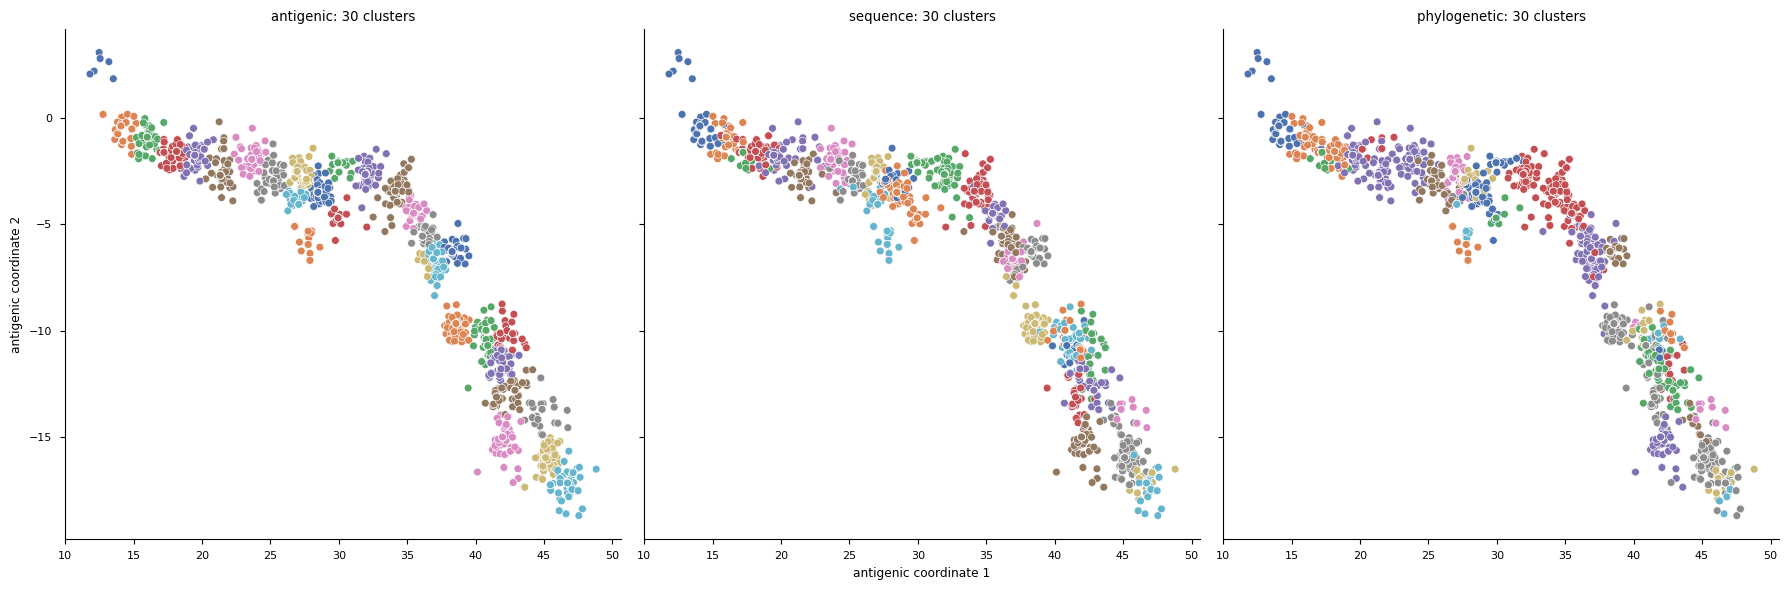

In [89]:
# Plot antigenic space of all cluster labels 
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
axes = axes.flatten()
for i, cluster_label in enumerate(['variant_ag', 'variant_tsne', 'variant_phylo']):
    ax = axes[i]
    n_clusters = tips_df[cluster_label].nunique()
    sns.scatterplot(data=tips_df, x='ag1', y='ag2', palette='deep', hue=cluster_label, legend=False, ax=ax)
    # Use label map to get cleaner names
    cluster_label_clean = method_labels.get(cluster_label, cluster_label)
    ax.set_title(f'{cluster_label_clean}: {n_clusters} clusters')
    if i == 1:
        ax.set_xlabel('antigenic coordinate 1')
    else:
        ax.set_xlabel('')
    ax.set_ylabel('antigenic coordinate 2')
    sns.despine()

plt.tight_layout()
# Save for pdf and png versions for publication
plt.savefig(os.path.join(fig_path, 'variant_assignment_clusters.pdf'), bbox_inches='tight')
plt.savefig(os.path.join(fig_path, 'variant_assignment_clusters.png'), bbox_inches='tight', dpi=300)
plt.show()

## Calculate variance of fitness across variant labels

In [35]:
# Now create a loop to do this for every time point
all_results = {
    'year': [],
    **{col: [] for col in variant_cols}
}
var_counts = {
    'year': [],
    **{col: [] for col in variant_cols}
}
time_points = sorted(host_memory_df['year'].unique())
for t in time_points:    
    # Get host coordinates at time t
    host_coords_t = (host_memory_df.loc[host_memory_df['year'] == t, 'ag1'].values[0],
                     host_memory_df.loc[host_memory_df['year'] == t, 'ag2'].values[0])
    
    
    # Calculate fitness for tips at time t
    tips_with_fitness_df = calculate_fitness_of_tips(
        tips_df,
        host_coordinates=host_coords_t
    )
    
    # Calculate variance in fitness for each variant assignment method
    results = {}
    for var_col in variant_cols:
        variances = tips_with_fitness_df.groupby(var_col)['fitness'].var()
        results[var_col] = variances.mean()

        # Subset dataframe to be only tips between t-1 and t
        year_mask = (tips_with_fitness_df['year'] > t - 1) & (tips_with_fitness_df['year'] <= t)
        masked_tips_df = tips_with_fitness_df[year_mask]
        n_variants = masked_tips_df[var_col].nunique()
        var_counts[var_col].append(n_variants)
        

    # Store results
    all_results['year'].append(t)
    var_counts['year'].append(t)
    for var_col in variant_cols:
        all_results[var_col].append(results[var_col])

In [36]:
all_results_df = pd.DataFrame(all_results)
all_results_df.head()

,year,variant_naive,variant_ag,variant_phylo,variant_mds,variant_pca,variant_tsne,variant_umap
0,0.0,0.000387,0.000120,0.000551,0.000328,0.000289,0.000333,0.000759
1,1.0,0.000402,0.000122,0.000624,0.000369,0.000331,0.000380,0.000844
2,2.0,0.000547,0.000138,0.000916,0.000428,0.000391,0.000460,0.001027
3,3.0,0.000695,0.000134,0.000962,0.000464,0.000425,0.000488,0.001441
4,4.0,0.000772,0.000159,0.001057,0.000569,0.000550,0.000551,0.001898


In [37]:
var_counts_df = pd.DataFrame(var_counts)
var_counts_df.head()

,year,variant_naive,variant_ag,variant_phylo,variant_mds,variant_pca,variant_tsne,variant_umap
0,0.0,1,2,1,2,2,1,1
1,1.0,1,3,2,3,3,2,3
2,2.0,1,3,4,4,4,4,4
3,3.0,1,3,4,3,3,4,6
4,4.0,1,4,4,4,4,5,6


## Main performance stats: variant counts and average variance of fitness over time

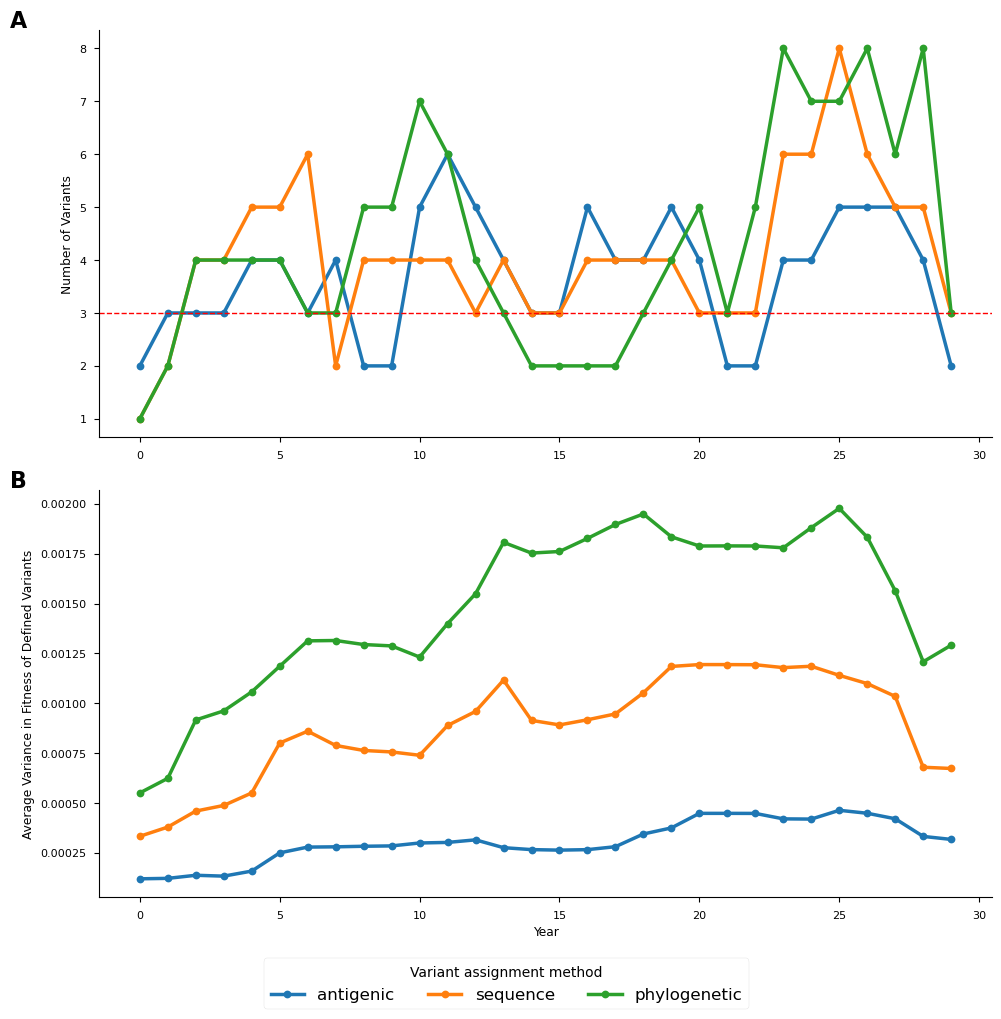

In [87]:
# Create combined 2x1 plot with shared legend
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

# Top panel: Variant counts over time
for var_col in ['variant_ag', 'variant_tsne', 'variant_phylo']:
    ax1.plot(var_counts_df['year'], var_counts_df[var_col], linewidth=2.5, marker='o', label=var_col)
ax1.axhline(y=3, color='red', linestyle='--', linewidth=1)
ax1.set_ylabel('Number of Variants')
sns.despine(ax=ax1)

# Bottom panel: Average variance in fitness over time
for var_col in ['variant_ag', 'variant_tsne', 'variant_phylo']:
    ax2.plot(all_results_df['year'], all_results_df[var_col], linewidth=2.5, marker='o', label=var_col)
ax2.set_xlabel('Year')
ax2.set_ylabel('Average Variance in Fitness of Defined Variants')
sns.despine(ax=ax2)

# Add panel labels
ax1.text(-0.1, 1.05, 'A', transform=ax1.transAxes, fontsize=16, fontweight='bold', va='top')
ax2.text(-0.1, 1.05, 'B', transform=ax2.transAxes, fontsize=16, fontweight='bold', va='top')

# Get handles and labels for shared legend
handles, labels = ax2.get_legend_handles_labels()
new_labels = [method_labels.get(label, label) for label in labels]

# Add shared legend below the figure
fig.legend(handles, new_labels, title='Variant assignment method', fontsize=12, 
           title_fontsize=10, loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=3)

plt.tight_layout()
plt.subplots_adjust(bottom=0.1)  # Make room for legend

# Save for manuscript
plt.savefig(os.path.join(fig_path, 'variant_counts_and_variance_combined.pdf'), bbox_inches='tight')
plt.savefig(os.path.join(fig_path, 'variant_counts_and_variance_combined.png'), bbox_inches='tight', dpi=300)
plt.show()

### Individual plot: Number of defined variants in a year

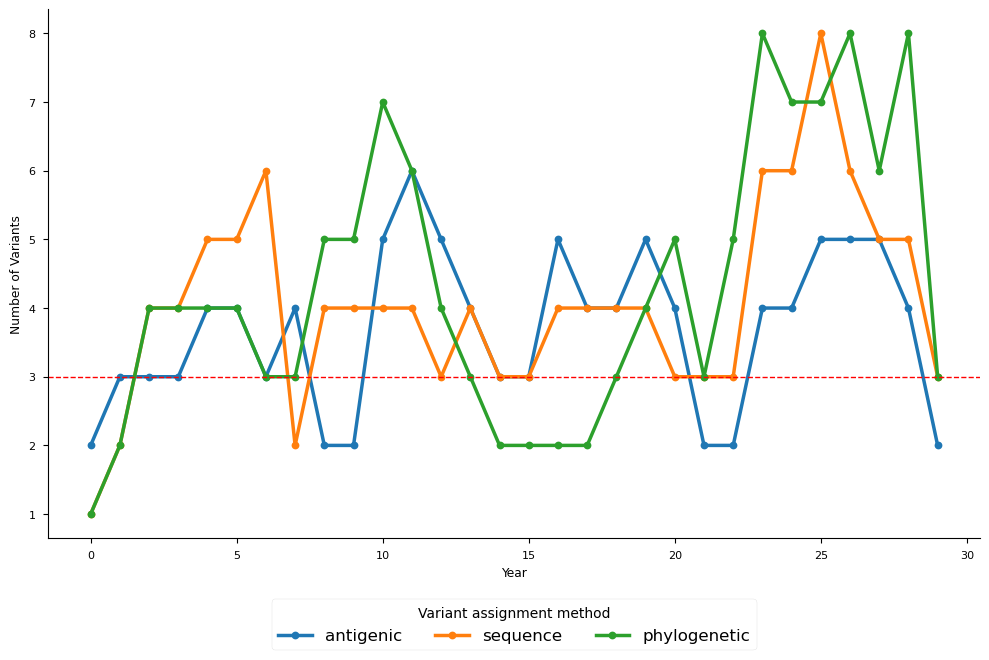

In [43]:
# Now create a lineplot to visualize the results
plt.figure(figsize=(10, 6))
for var_col in ['variant_ag', 'variant_tsne', 'variant_phylo']:
    plt.plot(var_counts_df['year'], var_counts_df[var_col], linewidth=2.5, marker='o', label=var_col)
plt.axhline(y=3, color='red', linestyle='--', linewidth=1)
plt.xlabel('Year')
plt.ylabel('Number of Variants')
#plt.title('Average Variance in Fitness of Defined Variants by Variant Assignment Method Over Time')
# Remove top and right spines
sns.despine()
plt.tight_layout()
#Get current handles and labels from the plot
handles, labels = plt.gca().get_legend_handles_labels()

# Create new labels by mapping the old ones
new_labels = [method_labels.get(label, label) for label in labels]

plt.legend(handles, new_labels, title='Variant assignment method', fontsize=12, 
           title_fontsize=10, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3)
# Save for pdf and png versions for publication
plt.savefig(os.path.join(fig_path, 'variant_counts_over_time.pdf'), bbox_inches='tight')
plt.savefig(os.path.join(fig_path, 'variant_counts_over_time.png'), bbox_inches='tight', dpi=300)
plt.show()

### Individual plot: Average variant variance over time

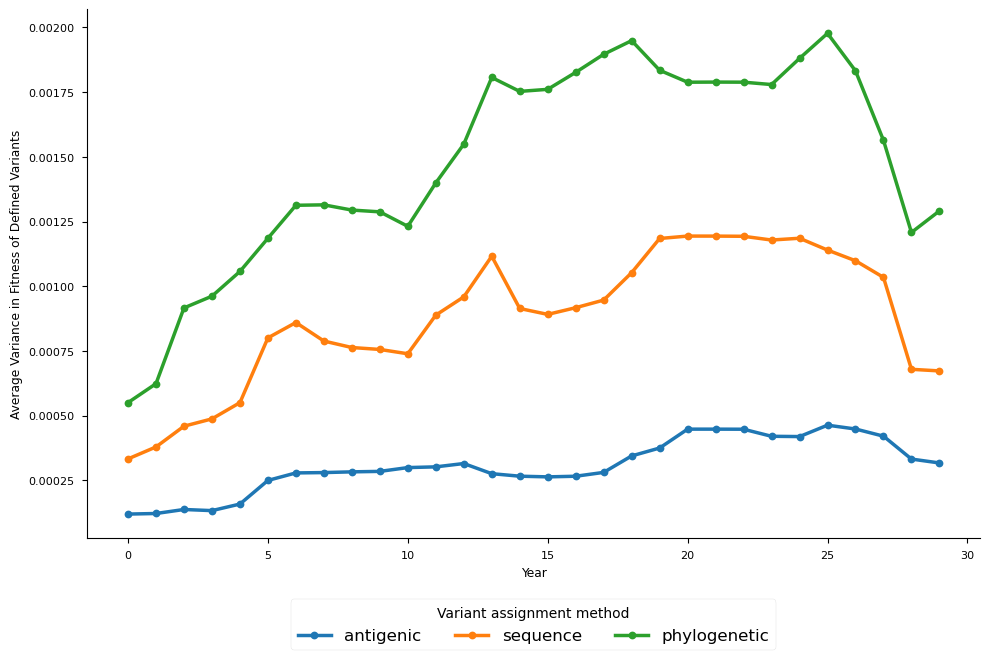

In [44]:
# Now create a lineplot to visualize the results
plt.figure(figsize=(10, 6))
for var_col in ['variant_ag', 'variant_tsne', 'variant_phylo']:
    plt.plot(all_results_df['year'], all_results_df[var_col], linewidth=2.5, marker='o', label=var_col)
plt.xlabel('Year')
plt.ylabel('Average Variance in Fitness of Defined Variants')
#plt.title('Average Variance in Fitness of Defined Variants by Variant Assignment Method Over Time')
# Remove top and right spines
sns.despine()
plt.tight_layout()
#Get current handles and labels from the plot
handles, labels = plt.gca().get_legend_handles_labels()

# Create new labels by mapping the old ones
new_labels = [method_labels.get(label, label) for label in labels]

# Replace the legend with properly mapped labels -- place under the plot
plt.legend(handles, new_labels, title='Variant assignment method', fontsize=12, 
           title_fontsize=10, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3)
# Save for pdf and png versions for publication
plt.savefig(os.path.join(fig_path, 'average_variance_over_time.pdf'), bbox_inches='tight')
plt.savefig(os.path.join(fig_path, 'average_variance_over_time.png'), bbox_inches='tight', dpi=300)
plt.show()

## Bubble plot: Variant assignment comparisons

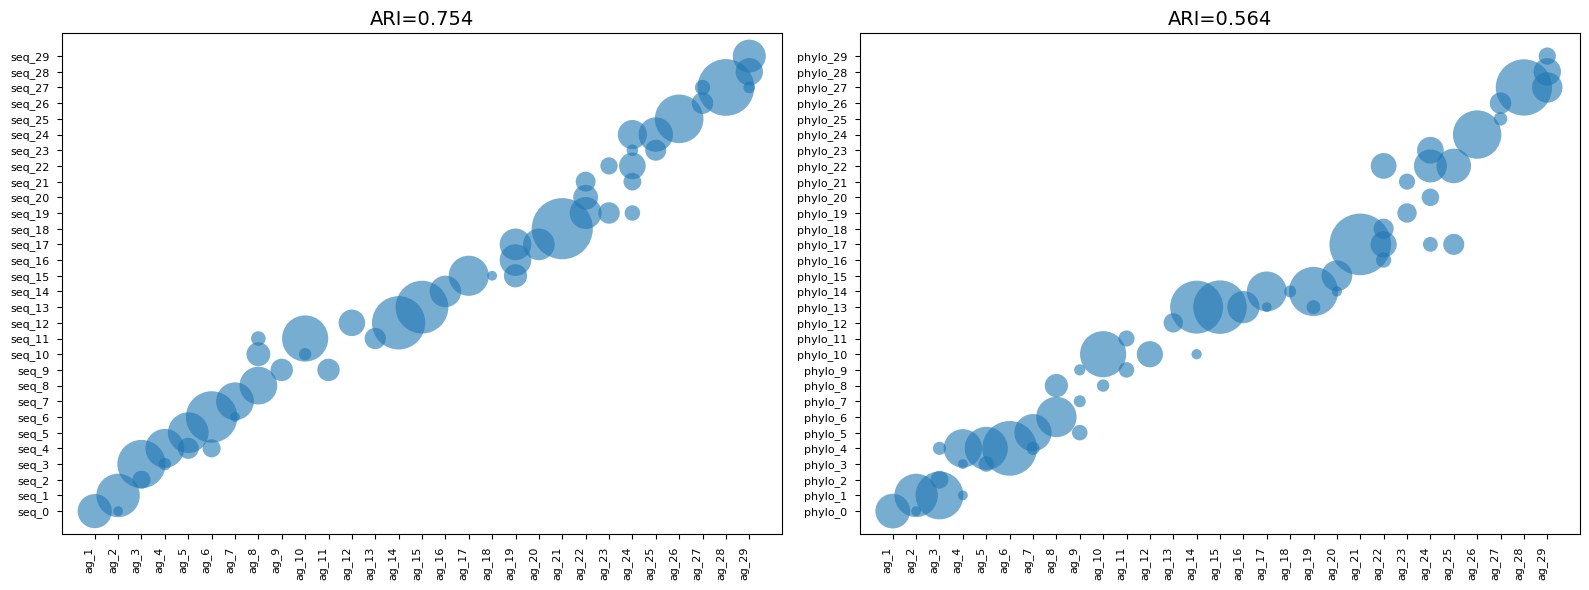

In [80]:
# Now create a 2x1 figure to hold both plots side by side using the modified function
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Create plots on specific axes
plot_variant_comparison(tips_df, method_x='ag', method_y='tsne', ax=ax1)
plot_variant_comparison(tips_df, method_x='ag', method_y='phylo', ax=ax2, show_legend=False)

plt.tight_layout()

# Save for pdf and png versions for publication
plt.savefig(os.path.join(fig_path, 'variant_bubble_plots.pdf'), bbox_inches='tight')
plt.savefig(os.path.join(fig_path, 'variant_bubble_plots.png'), bbox_inches='tight', dpi=300)
plt.show()